# DATA266 Lab 1 - Task 3: CycleGAN Monet ↔ Photo (Aswin)

This notebook implements, trains, evaluates, and exports a CycleGAN for the Kaggle competition. It is designed for Google Colab or Jupyter on an NVIDIA GPU. Run every cell in order.

**Integrity:** submitted images must be direct outputs of these trained generators. Do not hand-edit, cherry-pick, copy, or use pretrained/foundation generators. Pretrained Inception/LPIPS networks are loaded only after training for standard evaluation metrics and never modify submitted images.

Architecture: two 9-block ResNet generators with resize-convolution upsampling, two two-scale PatchGAN discriminators, least-squares GAN loss, cycle and identity losses, replay buffers, automatic mixed precision, and exponential-moving-average generators. This is a strong, stable lab-scale design; leaderboard superiority cannot be guaranteed before empirical comparison.

In [1]:
# Run once per fresh Colab runtime. Existing compatible packages are retained.
import importlib.util, subprocess, sys
required = {
    'torchmetrics': 'torchmetrics[image]',
    'torch_fidelity': 'torch-fidelity',
    'lpips': 'lpips',
    'pandas': 'pandas',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'kaggle': 'kaggle',
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print('Dependencies ready')

Dependencies ready


## 1. Configuration
Set `DATA_ROOT` to the folder containing `monet_jpg/` and `photo_jpg/`. On Colab, either upload/extract the competition data into `/content/data`, mount Drive, or enable `DOWNLOAD_WITH_KAGGLE` after securely uploading `kaggle.json`. Never commit `kaggle.json`.

In [2]:
from dataclasses import dataclass, asdict
from pathlib import Path
from copy import deepcopy
from collections import deque
import csv, gc, hashlib, json, math, os, platform, random, shutil, subprocess, sys, time, zipfile

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.utils import make_grid, save_image

IN_COLAB = 'google.colab' in sys.modules
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else platform.processor())
if DEVICE.type != 'cuda':
    print('WARNING: full training is intended for an NVIDIA GPU; use smoke mode only on CPU.')

@dataclass
class Config:
    seed: int = 26631
    image_size: int = 256
    batch_size: int = 1
    num_workers: int = 2
    epochs: int = 100
    decay_start_epoch: int = 50
    steps_per_epoch: int = 0  # 0 means one step per training Monet image
    generator_filters: int = 64
    discriminator_filters: int = 64
    residual_blocks: int = 9
    discriminator_scales: int = 2
    lr_g: float = 2e-4
    lr_d: float = 1e-4
    beta1: float = 0.5
    beta2: float = 0.999
    lambda_cycle: float = 10.0
    lambda_identity: float = 5.0
    replay_size: int = 50
    grad_clip: float = 10.0
    ema_decay: float = 0.999
    val_fraction: float = 0.10
    checkpoint_every: int = 5
    metric_samples: int = 1000
    run_id: str = 'aswin_cyclegan_v1'
    smoke: bool = False

CFG = Config()
if CFG.smoke:
    CFG.image_size, CFG.epochs, CFG.steps_per_epoch = 64, 1, 2
    CFG.generator_filters, CFG.discriminator_filters, CFG.residual_blocks = 16, 16, 2

# Edit only these paths/settings when moving between local Jupyter and Colab.
USE_GOOGLE_DRIVE = True
if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
DATA_ROOT = Path('/content/data') if IN_COLAB else Path.cwd() / 'task3_gan' / 'data'
WORK_ROOT = (Path('/content/drive/MyDrive/DATA266/task3_aswin') if IN_COLAB and USE_GOOGLE_DRIVE else (Path('/content/task3_aswin') if IN_COLAB else Path.cwd() / 'task3_gan' / 'member_aswin'))
DOWNLOAD_WITH_KAGGLE = False
COMPETITION_SLUG = ''  # paste the exact class competition slug if downloading/submitting via API
KAGGLE_JSON = Path('/content/kaggle.json')

CHECKPOINT_DIR = WORK_ROOT / 'checkpoints' / CFG.run_id
OUTPUT_DIR = WORK_ROOT / 'outputs'
PLOT_DIR = OUTPUT_DIR / 'plots'
A2B_DIR = OUTPUT_DIR / 'pred_A2B'
B2A_DIR = OUTPUT_DIR / 'pred_B2A'
AUDIT_DIR = OUTPUT_DIR / 'audit'
LOG_DIR = WORK_ROOT / 'logs'
for folder in [CHECKPOINT_DIR, PLOT_DIR, A2B_DIR, B2A_DIR, AUDIT_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
(CHECKPOINT_DIR / 'config.json').write_text(json.dumps(asdict(CFG), indent=2))
print('Data root:', DATA_ROOT)
print('Run output:', WORK_ROOT)

Device: cuda NVIDIA GeForce RTX 4090
Data root: /app/task3_gan/data
Run output: /app/task3_gan/member_aswin


In [3]:
# Optional Kaggle download. Upload kaggle.json to the runtime first; it is moved to a private location.
if DOWNLOAD_WITH_KAGGLE:
    if not COMPETITION_SLUG:
        raise ValueError('Set COMPETITION_SLUG to the exact competition slug.')
    if not KAGGLE_JSON.exists():
        raise FileNotFoundError('Upload kaggle.json to the path in KAGGLE_JSON.')
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(exist_ok=True)
    credential = kaggle_dir / 'kaggle.json'
    shutil.copy2(KAGGLE_JSON, credential)
    credential.chmod(0o600)
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    subprocess.run(['kaggle', 'competitions', 'download', '-c', COMPETITION_SLUG, '-p', str(DATA_ROOT)], check=True)
    for archive in DATA_ROOT.glob('*.zip'):
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(DATA_ROOT)

def image_files(folder):
    extensions = {'.jpg', '.jpeg', '.png'}
    return sorted(path for path in Path(folder).rglob('*') if path.suffix.lower() in extensions)

MONET_DIR = DATA_ROOT / 'monet_jpg'
PHOTO_DIR = DATA_ROOT / 'photo_jpg'
monet_files, photo_files = image_files(MONET_DIR), image_files(PHOTO_DIR)
if not monet_files or not photo_files:
    raise FileNotFoundError(f'Expected images under {MONET_DIR} and {PHOTO_DIR}. Found {len(monet_files)} Monet and {len(photo_files)} photos.')
print(f'Monet images: {len(monet_files):,}; photo images: {len(photo_files):,}')
print('Example Monet:', monet_files[0].name, 'Example photo:', photo_files[0].name)

Monet images: 300; photo images: 7,038
Example Monet: 000c1e3bff.jpg Example photo: 00068bc07f.jpg


## 2. Reproducible unpaired data pipeline
Each domain is split independently with the same recorded seed. Training uses resize, random crop, and horizontal flip. Validation and metrics use deterministic resizing. Domain B is sampled independently, so no artificial pairing is introduced.

{'seed': 26631, 'train_A': 270, 'val_A': 30, 'train_B': 6334, 'val_B': 704}


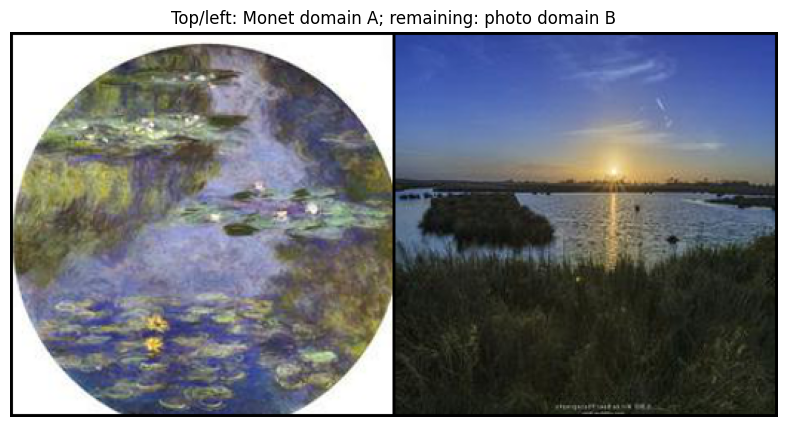

In [4]:
def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(CFG.seed)

def seeded_split(paths, val_fraction, seed):
    items = list(paths)
    rng = random.Random(seed); rng.shuffle(items)
    n_val = max(1, round(len(items) * val_fraction))
    return items[n_val:], items[:n_val]

train_A, val_A = seeded_split(monet_files, CFG.val_fraction, CFG.seed)
train_B, val_B = seeded_split(photo_files, CFG.val_fraction, CFG.seed + 1)

train_transform = transforms.Compose([
    transforms.Resize(int(CFG.image_size * 1.12), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(CFG.image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,) * 3, (0.5,) * 3),
])
eval_transform = transforms.Compose([
    transforms.Resize((CFG.image_size, CFG.image_size), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5,) * 3, (0.5,) * 3),
])

class UnpairedDataset(Dataset):
    def __init__(self, paths_a, paths_b, transform, seed, length=None):
        self.a, self.b, self.transform, self.seed = list(paths_a), list(paths_b), transform, seed
        self.length = length or len(self.a)
    def __len__(self): return self.length
    def __getitem__(self, index):
        rng = random.Random(self.seed + index + random.randint(0, 10_000_000))
        a_path = self.a[index % len(self.a)]
        b_path = self.b[rng.randrange(len(self.b))]
        with Image.open(a_path) as image: a = self.transform(image.convert('RGB'))
        with Image.open(b_path) as image: b = self.transform(image.convert('RGB'))
        return {'A': a, 'B': b, 'a_name': a_path.name, 'b_name': b_path.name}

class ImagePathDataset(Dataset):
    def __init__(self, paths, transform): self.paths, self.transform = list(paths), transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, index):
        path = self.paths[index]
        with Image.open(path) as image: tensor = self.transform(image.convert('RGB'))
        return tensor, path.name

epoch_length = CFG.steps_per_epoch * CFG.batch_size if CFG.steps_per_epoch else len(train_A)
train_ds = UnpairedDataset(train_A, train_B, train_transform, CFG.seed, epoch_length)
train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
val_loader = DataLoader(UnpairedDataset(val_A, val_B, eval_transform, CFG.seed + 9, min(len(val_A), len(val_B))), batch_size=1, shuffle=False, num_workers=CFG.num_workers)
split_manifest = {'seed': CFG.seed, 'train_A': [p.name for p in train_A], 'val_A': [p.name for p in val_A], 'train_B': [p.name for p in train_B], 'val_B': [p.name for p in val_B]}
(WORK_ROOT / 'data_processed').mkdir(parents=True, exist_ok=True)
(WORK_ROOT / 'data_processed' / f'{CFG.run_id}_split.json').write_text(json.dumps(split_manifest, indent=2))
print({k: len(v) if isinstance(v, list) else v for k, v in split_manifest.items()})
batch = next(iter(train_loader))
grid = make_grid(torch.cat([batch['A'][:4], batch['B'][:4]]), nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 5)); plt.imshow(grid.permute(1, 2, 0)); plt.axis('off'); plt.title('Top/left: Monet domain A; remaining: photo domain B'); plt.show()

## 3. CycleGAN architecture
`G_A2B` translates Monet to photo and `G_B2A` translates photo to Monet. Each discriminator is a two-scale 70×70 PatchGAN wrapper. Nearest-neighbor resize followed by convolution avoids transposed-convolution checkerboard artifacts. Instance normalization is used throughout the generators.

In [5]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(channels, channels, 3, bias=False), nn.InstanceNorm2d(channels), nn.ReLU(True),
            nn.ReflectionPad2d(1), nn.Conv2d(channels, channels, 3, bias=False), nn.InstanceNorm2d(channels),
        )
    def forward(self, x): return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, base=64, blocks=9):
        super().__init__()
        layers = [nn.ReflectionPad2d(3), nn.Conv2d(3, base, 7, bias=False), nn.InstanceNorm2d(base), nn.ReLU(True)]
        channels = base
        for _ in range(2):
            layers += [nn.Conv2d(channels, channels * 2, 3, 2, 1, bias=False), nn.InstanceNorm2d(channels * 2), nn.ReLU(True)]
            channels *= 2
        layers += [ResBlock(channels) for _ in range(blocks)]
        for _ in range(2):
            layers += [nn.Upsample(scale_factor=2, mode='nearest'), nn.ReflectionPad2d(1), nn.Conv2d(channels, channels // 2, 3, bias=False), nn.InstanceNorm2d(channels // 2), nn.ReLU(True)]
            channels //= 2
        layers += [nn.ReflectionPad2d(3), nn.Conv2d(channels, 3, 7), nn.Tanh()]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def snconv(in_c, out_c, kernel=4, stride=2, padding=1, norm=True):
    layers = [nn.utils.spectral_norm(nn.Conv2d(in_c, out_c, kernel, stride, padding))]
    if norm: layers.append(nn.InstanceNorm2d(out_c))
    layers.append(nn.LeakyReLU(0.2, True))
    return layers

class PatchDiscriminator(nn.Module):
    def __init__(self, base=64):
        super().__init__()
        self.net = nn.Sequential(
            *snconv(3, base, norm=False), *snconv(base, base * 2), *snconv(base * 2, base * 4),
            *snconv(base * 4, base * 8, stride=1), nn.utils.spectral_norm(nn.Conv2d(base * 8, 1, 4, 1, 1)),
        )
    def forward(self, x): return self.net(x)

class MultiScaleDiscriminator(nn.Module):
    def __init__(self, base=64, scales=2):
        super().__init__(); self.discriminators = nn.ModuleList([PatchDiscriminator(base) for _ in range(scales)])
    def forward(self, x):
        outputs = []
        for index, discriminator in enumerate(self.discriminators):
            outputs.append(discriminator(x))
            if index + 1 < len(self.discriminators): x = F.avg_pool2d(x, 3, 2, 1, count_include_pad=False)
        return outputs

def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        weight = module.weight_orig if hasattr(module, 'weight_orig') else module.weight
        nn.init.normal_(weight, 0.0, 0.02)
        if module.bias is not None: nn.init.zeros_(module.bias)

G_A2B = Generator(CFG.generator_filters, CFG.residual_blocks).to(DEVICE)
G_B2A = Generator(CFG.generator_filters, CFG.residual_blocks).to(DEVICE)
D_A = MultiScaleDiscriminator(CFG.discriminator_filters, CFG.discriminator_scales).to(DEVICE)
D_B = MultiScaleDiscriminator(CFG.discriminator_filters, CFG.discriminator_scales).to(DEVICE)
for model in [G_A2B, G_B2A, D_A, D_B]: model.apply(init_weights)
EMA_A2B, EMA_B2A = deepcopy(G_A2B).eval(), deepcopy(G_B2A).eval()
for model in [EMA_A2B, EMA_B2A]:
    for parameter in model.parameters(): parameter.requires_grad_(False)

def count_parameters(model): return sum(p.numel() for p in model.parameters())
parameter_counts = {name: count_parameters(model) for name, model in {'G_A2B': G_A2B, 'G_B2A': G_B2A, 'D_A': D_A, 'D_B': D_B}.items()}
print(parameter_counts, 'total=', sum(parameter_counts.values()))
with torch.no_grad():
    test = torch.randn(1, 3, CFG.image_size, CFG.image_size, device=DEVICE)
    assert G_A2B(test).shape == test.shape
    assert len(D_A(test)) == CFG.discriminator_scales
print('Architecture shape test passed')

{'G_A2B': 11372931, 'G_B2A': 11372931, 'D_A': 5529474, 'D_B': 5529474} total= 33804810
Architecture shape test passed


## 4. Losses, replay buffer, logging, and checkpointing
The objective is LSGAN adversarial loss + 10× cycle L1 + 5× identity L1. Discriminator replay buffers reduce oscillation. Gradient norms, non-finite losses, throughput, peak GPU memory, and wall time are recorded.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity=50): self.capacity, self.items = capacity, []
    def query(self, batch):
        returned = []
        for image in batch.detach():
            image = image.unsqueeze(0)
            if len(self.items) < self.capacity:
                self.items.append(image); returned.append(image)
            elif random.random() > 0.5:
                index = random.randrange(self.capacity); old = self.items[index].clone(); self.items[index] = image; returned.append(old)
            else: returned.append(image)
        return torch.cat(returned)

def gan_loss(predictions, real):
    target = 1.0 if real else 0.0
    return sum(F.mse_loss(prediction, torch.full_like(prediction, target)) for prediction in predictions) / len(predictions)

def grad_norm(parameters):
    norms = [p.grad.detach().norm(2) for p in parameters if p.grad is not None]
    return float(torch.stack(norms).norm(2).item()) if norms else 0.0

@torch.no_grad()
def update_ema(ema, model, decay):
    for ema_p, model_p in zip(ema.parameters(), model.parameters()): ema_p.mul_(decay).add_(model_p, alpha=1 - decay)
    for ema_b, model_b in zip(ema.buffers(), model.buffers()): ema_b.copy_(model_b)

def set_requires_grad(models, value):
    for model in models:
        for parameter in model.parameters(): parameter.requires_grad_(value)

optimizer_G = torch.optim.Adam(list(G_A2B.parameters()) + list(G_B2A.parameters()), lr=CFG.lr_g, betas=(CFG.beta1, CFG.beta2))
optimizer_D = torch.optim.Adam(list(D_A.parameters()) + list(D_B.parameters()), lr=CFG.lr_d, betas=(CFG.beta1, CFG.beta2))

def lr_lambda(epoch):
    if epoch < CFG.decay_start_epoch: return 1.0
    return max(0.0, 1.0 - (epoch - CFG.decay_start_epoch) / max(1, CFG.epochs - CFG.decay_start_epoch))
scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda)
scheduler_D = torch.optim.lr_scheduler.LambdaLR(optimizer_D, lr_lambda)
AMP_ENABLED = DEVICE.type == 'cuda'
if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
    # PyTorch 2.3+ API.
    scaler_G = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)
    scaler_D = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)
    def autocast_context(): return torch.amp.autocast('cuda', enabled=AMP_ENABLED)
else:
    # Compatibility with older PyTorch Docker images.
    scaler_G = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
    scaler_D = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
    def autocast_context(): return torch.cuda.amp.autocast(enabled=AMP_ENABLED)
buffer_A, buffer_B = ReplayBuffer(CFG.replay_size), ReplayBuffer(CFG.replay_size)
history, nan_count, images_seen = [], 0, 0
best_cycle = float('inf')
if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats()

def save_checkpoint(path, epoch):
    torch.save({
        'epoch': epoch, 'config': asdict(CFG), 'G_A2B': G_A2B.state_dict(), 'G_B2A': G_B2A.state_dict(),
        'D_A': D_A.state_dict(), 'D_B': D_B.state_dict(), 'EMA_A2B': EMA_A2B.state_dict(), 'EMA_B2A': EMA_B2A.state_dict(),
        'optimizer_G': optimizer_G.state_dict(), 'optimizer_D': optimizer_D.state_dict(), 'history': history,
        'nan_count': nan_count, 'parameter_counts': parameter_counts,
    }, path)

@torch.no_grad()
def validation_cycle_l1():
    EMA_A2B.eval(); EMA_B2A.eval(); total = count = 0
    for batch in val_loader:
        real_a, real_b = batch['A'].to(DEVICE), batch['B'].to(DEVICE)
        rec_a = EMA_B2A(EMA_A2B(real_a)); rec_b = EMA_A2B(EMA_B2A(real_b))
        total += F.l1_loss(rec_a, real_a).item() + F.l1_loss(rec_b, real_b).item(); count += 2
    return total / max(count, 1)

## 5. Train
The default run performs 100 epochs, with one update per training Monet image per epoch and linear LR decay after epoch 50. On a fresh run, execute this cell once and preserve the resulting raw JSONL log. If interrupted, change the run ID or add an explicit resume workflow; do not silently overwrite evidence.

In [7]:
raw_log_path = LOG_DIR / f'{CFG.run_id}.jsonl'
training_started = time.perf_counter()
for epoch in range(CFG.epochs):
    G_A2B.train(); G_B2A.train(); D_A.train(); D_B.train()
    sums = {key: 0.0 for key in ['g_total', 'g_adv', 'cycle', 'identity', 'd_a', 'd_b', 'grad_g', 'grad_d']}
    valid_steps = 0
    for step, batch in enumerate(train_loader):
        real_a = batch['A'].to(DEVICE, non_blocking=True); real_b = batch['B'].to(DEVICE, non_blocking=True)
        set_requires_grad([D_A, D_B], False); optimizer_G.zero_grad(set_to_none=True)
        with autocast_context():
            fake_b = G_A2B(real_a); fake_a = G_B2A(real_b)
            rec_a = G_B2A(fake_b); rec_b = G_A2B(fake_a)
            id_a = G_B2A(real_a); id_b = G_A2B(real_b)
            loss_g_adv = gan_loss(D_B(fake_b), True) + gan_loss(D_A(fake_a), True)
            loss_cycle = F.l1_loss(rec_a, real_a) + F.l1_loss(rec_b, real_b)
            loss_identity = F.l1_loss(id_a, real_a) + F.l1_loss(id_b, real_b)
            loss_g = loss_g_adv + CFG.lambda_cycle * loss_cycle + CFG.lambda_identity * loss_identity
        if not torch.isfinite(loss_g): nan_count += 1; continue
        scaler_G.scale(loss_g).backward(); scaler_G.unscale_(optimizer_G)
        norm_g = grad_norm(list(G_A2B.parameters()) + list(G_B2A.parameters()))
        torch.nn.utils.clip_grad_norm_(list(G_A2B.parameters()) + list(G_B2A.parameters()), CFG.grad_clip)
        scaler_G.step(optimizer_G); scaler_G.update(); update_ema(EMA_A2B, G_A2B, CFG.ema_decay); update_ema(EMA_B2A, G_B2A, CFG.ema_decay)

        set_requires_grad([D_A, D_B], True); optimizer_D.zero_grad(set_to_none=True)
        replay_a, replay_b = buffer_A.query(fake_a), buffer_B.query(fake_b)
        with autocast_context():
            loss_d_a = 0.5 * (gan_loss(D_A(real_a), True) + gan_loss(D_A(replay_a), False))
            loss_d_b = 0.5 * (gan_loss(D_B(real_b), True) + gan_loss(D_B(replay_b), False))
            loss_d = loss_d_a + loss_d_b
        if not torch.isfinite(loss_d): nan_count += 1; continue
        scaler_D.scale(loss_d).backward(); scaler_D.unscale_(optimizer_D)
        norm_d = grad_norm(list(D_A.parameters()) + list(D_B.parameters()))
        torch.nn.utils.clip_grad_norm_(list(D_A.parameters()) + list(D_B.parameters()), CFG.grad_clip)
        scaler_D.step(optimizer_D); scaler_D.update()

        values = {'g_total': loss_g.item(), 'g_adv': loss_g_adv.item(), 'cycle': loss_cycle.item(), 'identity': loss_identity.item(), 'd_a': loss_d_a.item(), 'd_b': loss_d_b.item(), 'grad_g': norm_g, 'grad_d': norm_d}
        for key, value in values.items(): sums[key] += value
        valid_steps += 1; images_seen += real_a.size(0) + real_b.size(0)

    scheduler_G.step(); scheduler_D.step()
    val_cycle = validation_cycle_l1()
    epoch_row = {'epoch': epoch + 1, **{key: value / max(valid_steps, 1) for key, value in sums.items()}, 'val_cycle_l1': val_cycle, 'lr_g': optimizer_G.param_groups[0]['lr'], 'lr_d': optimizer_D.param_groups[0]['lr'], 'nan_count': nan_count}
    history.append(epoch_row)
    with raw_log_path.open('a', encoding='utf-8') as handle: handle.write(json.dumps(epoch_row) + '\n')
    if val_cycle < best_cycle:
        best_cycle = val_cycle; save_checkpoint(CHECKPOINT_DIR / 'best_model.pt', epoch + 1)
    if (epoch + 1) % CFG.checkpoint_every == 0 or epoch + 1 == CFG.epochs:
        save_checkpoint(CHECKPOINT_DIR / f'epoch_{epoch + 1:03d}.pt', epoch + 1)
    print(f"Epoch {epoch+1:03d}/{CFG.epochs} G={epoch_row['g_total']:.3f} D_A={epoch_row['d_a']:.3f} D_B={epoch_row['d_b']:.3f} cycle={epoch_row['cycle']:.3f} val_cycle={val_cycle:.3f}")

total_training_time = time.perf_counter() - training_started
save_checkpoint(CHECKPOINT_DIR / 'final_model.pt', CFG.epochs)
peak_memory_mb = torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == 'cuda' else float('nan')
training_images_per_sec = images_seen / max(total_training_time, 1e-9)
print({'training_seconds': total_training_time, 'images_per_second': training_images_per_sec, 'peak_gpu_memory_mb': peak_memory_mb, 'nan_count': nan_count})

Epoch 001/100 G=10.611 D_A=0.298 D_B=0.299 cycle=0.665 val_cycle=0.419
Epoch 002/100 G=9.698 D_A=0.217 D_B=0.222 cycle=0.605 val_cycle=0.331
Epoch 003/100 G=9.296 D_A=0.175 D_B=0.199 cycle=0.571 val_cycle=0.287
Epoch 004/100 G=8.926 D_A=0.162 D_B=0.190 cycle=0.539 val_cycle=0.296
Epoch 005/100 G=8.764 D_A=0.155 D_B=0.171 cycle=0.527 val_cycle=0.286
Epoch 006/100 G=8.344 D_A=0.155 D_B=0.176 cycle=0.498 val_cycle=0.251
Epoch 007/100 G=8.376 D_A=0.160 D_B=0.162 cycle=0.502 val_cycle=0.243
Epoch 008/100 G=7.851 D_A=0.159 D_B=0.168 cycle=0.467 val_cycle=0.242
Epoch 009/100 G=7.902 D_A=0.152 D_B=0.159 cycle=0.468 val_cycle=0.236
Epoch 010/100 G=7.765 D_A=0.159 D_B=0.174 cycle=0.461 val_cycle=0.211
Epoch 011/100 G=7.447 D_A=0.156 D_B=0.167 cycle=0.438 val_cycle=0.218
Epoch 012/100 G=7.404 D_A=0.161 D_B=0.165 cycle=0.436 val_cycle=0.189
Epoch 013/100 G=7.632 D_A=0.156 D_B=0.159 cycle=0.449 val_cycle=0.206
Epoch 014/100 G=7.568 D_A=0.141 D_B=0.159 cycle=0.444 val_cycle=0.202
Epoch 015/100 G=7.3

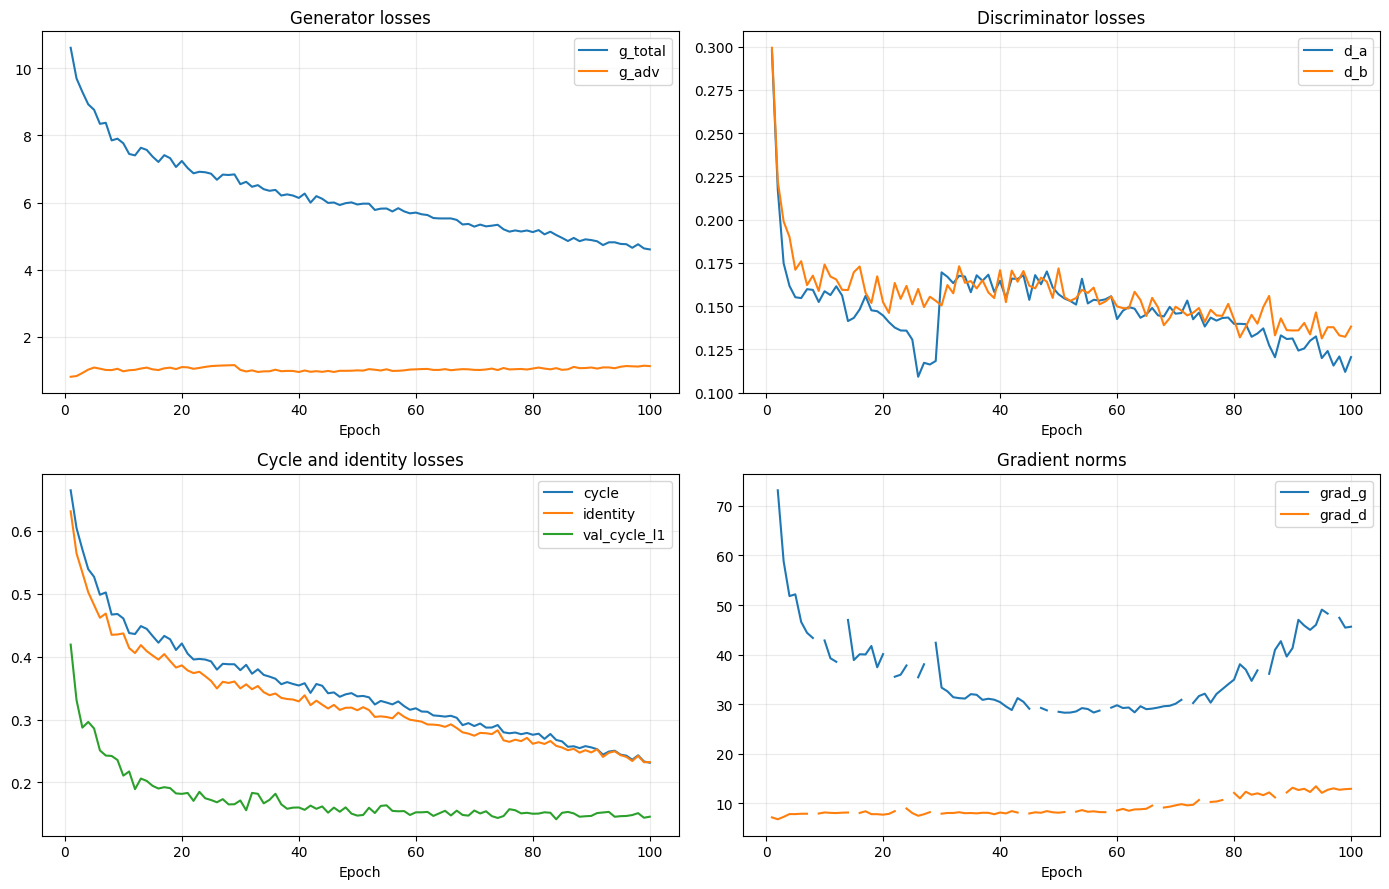

In [8]:
# Loss and stability plots
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / f'{CFG.run_id}_training_history.csv', index=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
history_df.plot(x='epoch', y=['g_total', 'g_adv'], ax=axes[0, 0], title='Generator losses')
history_df.plot(x='epoch', y=['d_a', 'd_b'], ax=axes[0, 1], title='Discriminator losses')
history_df.plot(x='epoch', y=['cycle', 'identity', 'val_cycle_l1'], ax=axes[1, 0], title='Cycle and identity losses')
history_df.plot(x='epoch', y=['grad_g', 'grad_d'], ax=axes[1, 1], title='Gradient norms')
for axis in axes.flat: axis.grid(alpha=0.25); axis.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(PLOT_DIR / f'{CFG.run_id}_training_curves.png', dpi=170); plt.show()

## 6. Load best checkpoint and generate both directions
All images are generated without manual selection. `pred_A2B` contains Monet→photo; `pred_B2A` contains photo→Monet. The latter is the usual submission direction for Monet-style competitions, but verify your class competition's exact rule.

In [9]:
checkpoint_path = CHECKPOINT_DIR / 'best_model.pt'
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
EMA_A2B.load_state_dict(checkpoint['EMA_A2B']); EMA_B2A.load_state_dict(checkpoint['EMA_B2A'])
EMA_A2B.eval(); EMA_B2A.eval()

@torch.inference_mode()
def translate_all(paths, generator, output_dir, limit=None):
    output_dir.mkdir(parents=True, exist_ok=True)
    loader = DataLoader(ImagePathDataset(paths[:limit] if limit else paths, eval_transform), batch_size=8, shuffle=False, num_workers=CFG.num_workers, pin_memory=True)
    count = 0; started = time.perf_counter()
    for images, names in loader:
        generated = generator(images.to(DEVICE, non_blocking=True)).cpu()
        for image, name in zip(generated, names):
            save_image((image + 1) / 2, output_dir / f'{Path(name).stem}.jpg')
            count += 1
    elapsed = time.perf_counter() - started
    return count, elapsed, count / max(elapsed, 1e-9)

a2b_stats = translate_all(monet_files, EMA_A2B, A2B_DIR, None if not CFG.smoke else 4)
b2a_stats = translate_all(photo_files, EMA_B2A, B2A_DIR, None if not CFG.smoke else 4)
print('A2B count/time/images_sec:', a2b_stats)
print('B2A count/time/images_sec:', b2a_stats)

A2B count/time/images_sec: (300, 3.959200711000449, 75.77286980335815)
B2A count/time/images_sec: (7038, 87.1607003470017, 80.74740074346025)


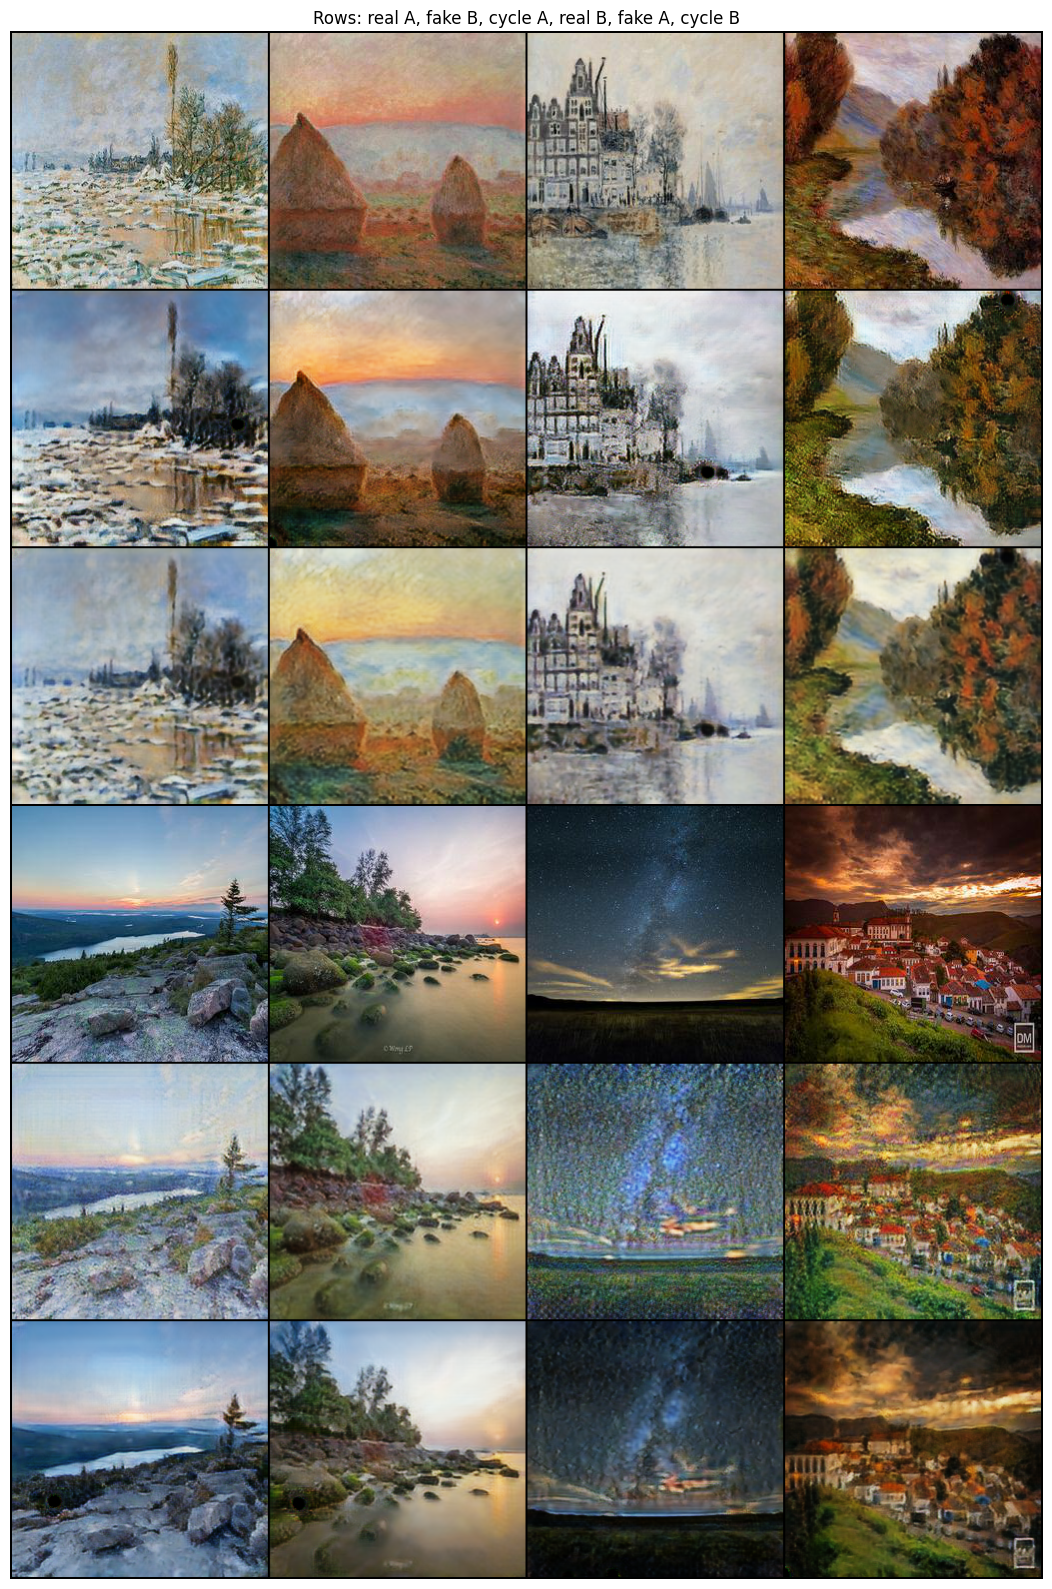

In [10]:
# Fixed qualitative comparison; this is evidence, not a hand-picked submission subset.
@torch.inference_mode()
def comparison_grid(paths_a, paths_b, n=4):
    tensors_a = torch.stack([eval_transform(Image.open(path).convert('RGB')) for path in paths_a[:n]]).to(DEVICE)
    tensors_b = torch.stack([eval_transform(Image.open(path).convert('RGB')) for path in paths_b[:n]]).to(DEVICE)
    fake_b, cycle_a = EMA_A2B(tensors_a), EMA_B2A(EMA_A2B(tensors_a))
    fake_a, cycle_b = EMA_B2A(tensors_b), EMA_A2B(EMA_B2A(tensors_b))
    grid = make_grid(torch.cat([tensors_a, fake_b, cycle_a, tensors_b, fake_a, cycle_b]).cpu(), nrow=n, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(14, 16)); plt.imshow(grid.permute(1, 2, 0)); plt.axis('off')
    plt.title('Rows: real A, fake B, cycle A, real B, fake A, cycle B')
    plt.tight_layout(); plt.savefig(PLOT_DIR / f'{CFG.run_id}_qualitative_grid.png', dpi=170); plt.show()
comparison_grid(val_A, val_B)

## 7. Required quantitative metrics
Standard FID/KID and Inception-feature precision/recall use a pretrained Inception network only as an evaluator. LPIPS likewise uses its standard evaluation network. These networks are never in the generation path. Scores from very small validation sets are noisy; report sample counts with every value.

In [11]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import lpips
from torchvision.models import inception_v3, Inception_V3_Weights

lpips_metric = lpips.LPIPS(net='alex').to(DEVICE).eval()
inception = inception_v3(weights=Inception_V3_Weights.DEFAULT)
inception.fc = nn.Identity(); inception.to(DEVICE).eval()

def to_uint8(images): return ((images.clamp(-1, 1) + 1) * 127.5).to(torch.uint8)

@torch.inference_mode()
def inception_features(images):
    images = F.interpolate((images + 1) / 2, size=(299, 299), mode='bilinear', align_corners=False)
    images = (images - torch.tensor([0.485, 0.456, 0.406], device=images.device)[None, :, None, None]) / torch.tensor([0.229, 0.224, 0.225], device=images.device)[None, :, None, None]
    return inception(images)

def manifold_precision_recall(real_features, fake_features, k=3):
    real_features, fake_features = real_features.float().cpu(), fake_features.float().cpu()
    rr = torch.cdist(real_features, real_features); ff = torch.cdist(fake_features, fake_features); rf = torch.cdist(real_features, fake_features)
    rr.fill_diagonal_(float('inf')); ff.fill_diagonal_(float('inf'))
    real_radius = rr.kthvalue(min(k, rr.shape[1] - 1), dim=1).values
    fake_radius = ff.kthvalue(min(k, ff.shape[1] - 1), dim=1).values
    precision = (rf <= real_radius[:, None]).any(dim=0).float().mean().item()
    recall = (rf <= fake_radius[None, :]).any(dim=1).float().mean().item()
    return precision, recall

@torch.inference_mode()
def collect_direction(source_paths, target_paths, generator, inverse_generator, max_samples):
    source_paths = source_paths[:max_samples]; target_paths = target_paths[:max_samples]
    source_loader = DataLoader(ImagePathDataset(source_paths, eval_transform), batch_size=8, shuffle=False, num_workers=CFG.num_workers)
    target_loader = DataLoader(ImagePathDataset(target_paths, eval_transform), batch_size=8, shuffle=False, num_workers=CFG.num_workers)
    kid_subset = max(2, min(50, len(source_paths), len(target_paths)))
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(DEVICE)
    kid = KernelInceptionDistance(feature=2048, subset_size=kid_subset, normalize=False).to(DEVICE)
    fake_features, real_features = [], []
    lpips_sum = cosine_sum = cycle_sum = 0.0; generated_n = 0
    for source, _ in source_loader:
        source = source.to(DEVICE); fake = generator(source); reconstructed = inverse_generator(fake)
        uint_fake = to_uint8(fake); fid.update(uint_fake, real=False); kid.update(uint_fake, real=False)
        source_feat, fake_feat = inception_features(source), inception_features(fake)
        fake_features.append(fake_feat.cpu())
        lpips_sum += lpips_metric(source, fake).sum().item()
        cosine_sum += F.cosine_similarity(source_feat, fake_feat, dim=1).sum().item()
        cycle_sum += F.l1_loss(reconstructed, source, reduction='sum').item() / (source.shape[1] * source.shape[2] * source.shape[3])
        generated_n += source.size(0)
    target_n = 0
    for target, _ in target_loader:
        target = target.to(DEVICE); uint_target = to_uint8(target)
        fid.update(uint_target, real=True); kid.update(uint_target, real=True)
        real_features.append(inception_features(target).cpu()); target_n += target.size(0)
    fake_features, real_features = torch.cat(fake_features), torch.cat(real_features)
    precision, recall = manifold_precision_recall(real_features, fake_features)
    kid_mean, kid_std = kid.compute()
    return {
        'fid': float(fid.compute()), 'kid_mean': float(kid_mean), 'kid_std': float(kid_std),
        'generative_precision': precision, 'generative_recall': recall,
        'cycle_reconstruction_l1': cycle_sum / generated_n, 'lpips': lpips_sum / generated_n,
        'content_cosine': cosine_sum / generated_n, 'generated_samples': generated_n, 'real_target_samples': target_n,
    }

metric_limit = min(CFG.metric_samples, len(monet_files), len(photo_files))
metrics_a2b = collect_direction(monet_files, photo_files, EMA_A2B, EMA_B2A, metric_limit)
metrics_b2a = collect_direction(photo_files, monet_files, EMA_B2A, EMA_A2B, metric_limit)
metrics_a2b['direction'] = 'A2B_monet_to_photo'; metrics_b2a['direction'] = 'B2A_photo_to_monet'
print('A2B', json.dumps(metrics_a2b, indent=2)); print('B2A', json.dumps(metrics_b2a, indent=2))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:13<00:00, 18.2MB/s] 
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


Loading model from: /opt/conda/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


100%|██████████| 104M/104M [00:05<00:00, 18.2MB/s] 
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:05<00:00, 17.7MB/s]
/opt/conda/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


A2B {
  "fid": 125.09461212158203,
  "kid_mean": 0.04360148310661316,
  "kid_std": 0.006114697549492121,
  "generative_precision": 0.5833333134651184,
  "generative_recall": 0.25999999046325684,
  "cycle_reconstruction_l1": 0.12311650832494098,
  "lpips": 0.3420094100634257,
  "content_cosine": 0.7923895645141602,
  "generated_samples": 300,
  "real_target_samples": 300,
  "direction": "A2B_monet_to_photo"
}
B2A {
  "fid": 122.65724182128906,
  "kid_mean": 0.028915537521243095,
  "kid_std": 0.004264409188181162,
  "generative_precision": 0.3033333420753479,
  "generative_recall": 0.6000000238418579,
  "cycle_reconstruction_l1": 0.13354738818274606,
  "lpips": 0.4164084315299988,
  "content_cosine": 0.7738105058670044,
  "generated_samples": 300,
  "real_target_samples": 300,
  "direction": "B2A_photo_to_monet"
}


In [12]:
# Consolidated metrics report. Human audit and leaderboard cells remain blank until real evidence is entered.
common = {
    'run_id': CFG.run_id, 'checkpoint': str(checkpoint_path), 'generator_loss_final': history[-1]['g_total'],
    'discriminator_A_loss_final': history[-1]['d_a'], 'discriminator_B_loss_final': history[-1]['d_b'],
    'cycle_loss_final': history[-1]['cycle'], 'identity_loss_final': history[-1]['identity'],
    'generator_grad_norm_mean': float(history_df['grad_g'].mean()), 'discriminator_grad_norm_mean': float(history_df['grad_d'].mean()),
    'nan_count': nan_count, 'parameter_count': sum(parameter_counts.values()), 'training_time_seconds': total_training_time,
    'training_images_per_second': training_images_per_sec, 'peak_memory_mb': peak_memory_mb,
    'hardware': torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else platform.processor(),
    'human_style_mean': '', 'human_content_mean': '', 'human_artifact_mean': '', 'human_agreement': '',
    'kaggle_public_score': '', 'kaggle_private_score': '', 'kaggle_rank': '',
}
report = pd.DataFrame([{**common, **metrics_a2b, 'generation_images_per_second': a2b_stats[2]}, {**common, **metrics_b2a, 'generation_images_per_second': b2a_stats[2]}])
report.to_csv(WORK_ROOT / 'full_metrics_report.csv', index=False)
display(report.T)

,0,1
run_id,aswin_cyclegan_v1,aswin_cyclegan_v1
checkpoint,/app/task3_gan/member_aswin/checkpoints/aswin_...,/app/task3_gan/member_aswin/checkpoints/aswin_...
generator_loss_final,4.602618,4.602618
discriminator_A_loss_final,0.120508,0.120508
discriminator_B_loss_final,0.138162,0.138162
cycle_loss_final,0.23143,0.23143
identity_loss_final,0.232502,0.232502
generator_grad_norm_mean,inf,inf
discriminator_grad_norm_mean,inf,inf
nan_count,0,0


## 8. Blinded human audit: 30 fixed samples, 2 raters
This cell deterministically produces 30 anonymized photo→Monet translations and a rating sheet. Give the images and CSV independently to two raters. Each rater scores `style`, `content`, and `artifacts` from 1 (poor) to 5 (excellent). For artifacts, 5 means artifact-free. Do not let one rater see the other's answers.

In [13]:
audit_rng = random.Random(CFG.seed + 100)
audit_sources = audit_rng.sample(photo_files, min(30, len(photo_files)))
audit_rows = []
with torch.inference_mode():
    for index, path in enumerate(audit_sources, 1):
        with Image.open(path) as image: source = eval_transform(image.convert('RGB')).unsqueeze(0).to(DEVICE)
        generated = EMA_B2A(source).cpu()[0]
        anonymous_id = f'sample_{index:02d}'
        save_image((generated + 1) / 2, AUDIT_DIR / f'{anonymous_id}.jpg')
        audit_rows.append({'sample_id': anonymous_id, 'rater1_style': '', 'rater1_content': '', 'rater1_artifacts': '', 'rater2_style': '', 'rater2_content': '', 'rater2_artifacts': ''})
audit_csv = WORK_ROOT / 'human_audit_30.csv'
pd.DataFrame(audit_rows).to_csv(audit_csv, index=False)
print('Audit images:', AUDIT_DIR); print('Rating sheet:', audit_csv)

Audit images: /app/task3_gan/member_aswin/outputs/audit
Rating sheet: /app/task3_gan/member_aswin/human_audit_30.csv


In [14]:
# Run only after both raters have completed every cell in human_audit_30.csv.
from sklearn.metrics import cohen_kappa_score
audit = pd.read_csv(audit_csv)
rating_columns = [f'rater{r}_{dimension}' for r in (1, 2) for dimension in ('style', 'content', 'artifacts')]
if audit[rating_columns].isna().any().any():
    print('Human audit is not complete; no scores are reported yet.')
else:
    audit_metrics = {}
    for dimension in ('style', 'content', 'artifacts'):
        r1, r2 = audit[f'rater1_{dimension}'].astype(int), audit[f'rater2_{dimension}'].astype(int)
        audit_metrics[f'human_{dimension}_mean'] = float(pd.concat([r1, r2]).mean())
        audit_metrics[f'{dimension}_weighted_kappa'] = float(cohen_kappa_score(r1, r2, weights='quadratic'))
    audit_metrics['human_agreement'] = float(np.mean([audit[f'rater1_{d}'].eq(audit[f'rater2_{d}']).mean() for d in ('style', 'content', 'artifacts')]))
    for key, value in audit_metrics.items(): report[key] = value
    report.to_csv(WORK_ROOT / 'full_metrics_report.csv', index=False)
    print(json.dumps(audit_metrics, indent=2))

Human audit is not complete; no scores are reported yet.


## 9. Kaggle package and submission
The usual Monet-style submission is every photo translated by `EMA_B2A`, zipped with the exact filenames expected by the competition. This cell packages all generated B→A images without cherry-picking. Check the class competition's submission page before uploading: some competitions expect `images.zip`, while the lab repository also requests a `submission.csv` manifest.

In [15]:
submission_manifest = pd.DataFrame({
    'image': [path.name for path in sorted(B2A_DIR.glob('*.jpg'))],
    'direction': 'B2A_photo_to_monet',
    'checkpoint': checkpoint_path.name,
})
submission_csv = WORK_ROOT / 'submission.csv'; submission_manifest.to_csv(submission_csv, index=False)
submission_zip = WORK_ROOT / 'images.zip'
with zipfile.ZipFile(submission_zip, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(B2A_DIR.glob('*.jpg')): archive.write(path, arcname=path.name)
print('Created', submission_zip, 'with', len(submission_manifest), 'model-generated images')

SUBMIT_TO_KAGGLE = False
if SUBMIT_TO_KAGGLE:
    if not COMPETITION_SLUG: raise ValueError('Set COMPETITION_SLUG first.')
    subprocess.run(['kaggle', 'competitions', 'submit', '-c', COMPETITION_SLUG, '-f', str(submission_zip), '-m', CFG.run_id], check=True)
    print('Submission sent. Record public/private scores and rank in full_metrics_report.csv after Kaggle evaluates it.')

Created /app/task3_gan/member_aswin/images.zip with 7038 model-generated images


## 10. Submission checklist

Before claiming Task 3 complete:

- Save this notebook with all outputs visible.
- Preserve `logs/<run_id>.jsonl`, `checkpoints/<run_id>/best_model.pt`, and the config.
- Confirm `full_metrics_report.csv` has both directions and no blank required model metrics.
- Complete the 30-sample audit with two independent raters and rerun its analysis cell.
- Submit only the complete, unedited model-output archive and record Kaggle public/private scores and rank.
- Write your own visual observations, convergence analysis, shortcomings, and model justification in `results.md`.
- Compare this completed architecture/config against your teammate's completed configuration before the final run.
- Capture an environment manifest and checkpoint hash for reproducibility.